# 1. Introduction

## Model Testing, Evaluation & Documentation – Recommendation System

In this notebook, I extend the previous recommendation system by focusing on model testing, evaluation, debugging, and documentation. The goal is to assess model reliability, identify common failure patterns, and improve reproducibility through structured testing methods.

This notebook builds on the previous recommendation pipeline and uses a temporal validation approach to better simulate real-world deployment conditions.

The objective is to create a reproducible and well-structured evaluation pipeline that can be extended in future development stages.

## 2. Load and Inspect Dataset

Load the dataset and take a quick look at the structure.

Main focus: user-product interactions.

In [1]:
import pandas as pd
from sklearn.decomposition import TruncatedSVD

orders = pd.read_csv(
    "orders.csv",
    usecols=["order_id", "user_id", "order_number", "days_since_prior_order"],
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "order_number": "int16",
        "days_since_prior_order": "float32"
    }
)

order_products = pd.read_csv(
    "order_products__prior.csv",
    usecols=["order_id", "product_id", "reordered"],
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "reordered": "int8"
    }
)

products = pd.read_csv(
    "products.csv",
    usecols=["product_id", "aisle_id"],
    dtype={"product_id": "int32", "aisle_id": "int16"}
)

print(orders.shape, order_products.shape, products.shape)

(3421083, 4) (32434489, 3) (49688, 2)


## 3. Reproducibility Setup

A fixed random seed is used to ensure that sampling and evaluation results remain reproducible across runs.

In [2]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

## 4. Data Preparation

The dataset is constructed by merging order-level and product-level data. A subset of users (2%) is sampled to reduce computational complexity while preserving representative user behavior patterns. This sampling strategy enables efficient experimentation without significantly affecting model performance trends.

In addition to user, product, and order information, the variables *days_since_prior_order*, *reordered*, and *aisle_id* are included to support feature engineering. An interaction variable is created to represent implicit feedback, where a value of 1 indicates a purchase.

Users with at least two orders are retained to ensure a meaningful time-based train-test split. This filtering step ensures that each user has sufficient historical data for model training and evaluation.

In [3]:
# Sample users (2%)
sample_users = orders["user_id"].drop_duplicates().sample(frac=0.02, random_state=42)

orders_small = orders[orders["user_id"].isin(sample_users)].copy()
order_ids_small = orders_small["order_id"].unique()

order_products_small = order_products[order_products["order_id"].isin(order_ids_small)].copy()

df = order_products_small.merge(orders_small, on="order_id")
df = df.merge(products, on="product_id", how="left")

df = df[["user_id", "product_id", "aisle_id", "order_number", "days_since_prior_order", "reordered"]]
df["interaction"] = 1

user_order_counts = df.groupby("user_id")["order_number"].nunique()
valid_users = user_order_counts[user_order_counts >= 2].index
df = df[df["user_id"].isin(valid_users)].copy()

print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (646425, 7)


,user_id,product_id,aisle_id,order_number,days_since_prior_order,reordered,interaction
0,98256,35108,36,29,6.0,0,1
1,98256,40593,108,29,6.0,1,1
2,98256,17461,35,29,6.0,0,1
3,98256,22825,24,29,6.0,1,1
4,98256,25256,84,29,6.0,1,1


## 5. Train/Test Split (Time-Based)

The data is split based on time, where past interactions are used for training and the latest interactions are used for testing.

The model is evaluated on unseen future interactions to simulate real-world recommendation scenarios.

In [4]:
df = df.sort_values(["user_id", "order_number"])

last_orders = df.groupby("user_id")["order_number"].transform("max")

train = df[df["order_number"] < last_orders].copy()
test = df[df["order_number"] == last_orders].copy()

print(train.shape, test.shape)

(603353, 7) (43072, 7)


## 6. Build User-Item Matrix

Build the user-item interaction matrix from training data.

In [5]:
user_item_matrix = train.pivot_table(
    index="user_id",
    columns="product_id",
    values="interaction",
    fill_value=0
)

user_item_matrix.shape

(4124, 26489)

To improve memory efficiency, intermediate data structures are cleared after constructing the user-item matrix.

In [6]:
del df
import gc
gc.collect()

0

## 7. Train Model (TruncatedSVD)

Based on the previous optimization results, the final recommendation model uses TruncatedSVD with n_components = 10, which achieved the best performance.

In [7]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=10, random_state=42)

latent_matrix = svd.fit_transform(user_item_matrix)
reconstructed_matrix = latent_matrix.dot(svd.components_)

## 8. Generate Top-10 Recommendations

Generate top-10 product recommendations for each user based on predicted scores.

In [8]:
reconstructed_df = pd.DataFrame(
    reconstructed_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

def get_top_n(user_id, n=10):
    user_scores = reconstructed_df.loc[user_id]

    seen_items = set(train[train["user_id"] == user_id]["product_id"])

    recommendations = [
        item for item in user_scores.sort_values(ascending=False).index
        if item not in seen_items
    ]

    return recommendations[:n]

# Example
sample_user = user_item_matrix.index[0]
get_top_n(sample_user)

[21137, 22935, 27966, 10749, 30391, 44359, 41950, 21938, 21903, 34126]

## 9. Evaluate Performance

Evaluate the model using Precision@10 (primary) and Recall@10 (secondary).

In [9]:
def precision_recall_at_k(user_id, k=10):
    recommended = set(get_top_n(user_id, k))
    actual = set(test[test["user_id"] == user_id]["product_id"])

    if len(actual) == 0:
        return 0, 0

    tp = len(recommended & actual)

    precision = tp / k
    recall = tp / len(actual)

    return precision, recall

precisions = []
recalls = []

for user in test["user_id"].unique():
    p, r = precision_recall_at_k(user)
    precisions.append(p)
    recalls.append(r)

print("Precision@10:", np.mean(precisions))
print("Recall@10:", np.mean(recalls))

Precision@10: 0.01966537342386033
Recall@10: 0.019550005172950885


## 10. Discussion

This baseline model provides an initial benchmark for recommendation performance.

At this stage, the focus is on understanding how well the model performs before applying more advanced testing and debugging techniques. The results from this section serve as a reference point for evaluating improvements in later stages.

The next sections build on this baseline by introducing temporal validation, error analysis, and reliability-focused evaluation.

## 11. Model Optimization (Hyperparameter Tuning)

This section is retained from the previous stage to show how the model was optimized before final testing. The results support the selection of n_components = 10 as the final model configuration.

In [10]:
from sklearn.decomposition import TruncatedSVD
import pandas as pd
import numpy as np

results = []

components_list = [10, 20, 50]

eval_users = pd.Series(test["user_id"].unique()).sample(
    n=min(500, len(test["user_id"].unique())),
    random_state=42
)

for n in components_list:
    svd_temp = TruncatedSVD(n_components=n, random_state=42)

    latent_matrix_temp = svd_temp.fit_transform(user_item_matrix)
    reconstructed_matrix_temp = latent_matrix_temp.dot(svd_temp.components_)

    reconstructed_df_temp = pd.DataFrame(
        reconstructed_matrix_temp,
        index=user_item_matrix.index,
        columns=user_item_matrix.columns
    )

    def get_top_n_temp(user_id, n_recs=10):
        user_scores = reconstructed_df_temp.loc[user_id]
        seen_items = set(train[train["user_id"] == user_id]["product_id"])

        recs = [
            item for item in user_scores.sort_values(ascending=False).index
            if item not in seen_items
        ]
        return recs[:n_recs]

    def precision_recall_at_k_temp(user_id, k=10):
        recommended = set(get_top_n_temp(user_id, k))
        actual = set(test[test["user_id"] == user_id]["product_id"])

        if len(actual) == 0:
            return 0, 0

        tp = len(recommended & actual)
        precision = tp / k
        recall = tp / len(actual)

        return precision, recall

    precisions_temp = []
    recalls_temp = []

    for user in eval_users:
        p, r = precision_recall_at_k_temp(user)
        precisions_temp.append(p)
        recalls_temp.append(r)

    results.append({
        "n_components": n,
        "precision": np.mean(precisions_temp),
        "recall": np.mean(recalls_temp)
    })

results_df = pd.DataFrame(results)
results_df

,n_components,precision,recall
0,10,0.0190,0.016928
1,20,0.0148,0.013174
2,50,0.0132,0.010730


## 12. Explainability Model (Logistic Regression)

In Week 4, an explainability framework was implemented using a Logistic Regression model and LIME to better understand model behavior. The analysis showed that features such as product_prior_count had the strongest influence on predictions, indicating that the model relies heavily on historical user-product interactions.

The model was trained using only training data to avoid data leakage and ensure a more realistic setup. Both positive (purchased) and negative (not purchased) samples were included.

Feature engineering was based on user interaction history, including total prior orders, product interaction frequency, user reorder behavior, time since the last order, and aisle-level purchase frequency.

In [11]:
from sklearn.linear_model import LogisticRegression

positive_df = train.sample(n=5000, random_state=42).copy()
positive_df["target"] = 1

all_products = train["product_id"].unique()

negative_rows = []

for user in positive_df["user_id"].unique():
    user_history = train[train["user_id"] == user]
    user_products = set(user_history["product_id"])

    candidate_products = list(set(all_products) - user_products)
    if len(candidate_products) == 0:
        continue

    sampled_products = np.random.choice(
        candidate_products,
        size=min(3, len(candidate_products)),
        replace=False
    )

    latest_order_number = user_history["order_number"].max()

    latest_days = user_history.sort_values("order_number")["days_since_prior_order"].dropna()
    latest_days_value = latest_days.iloc[-1] if len(latest_days) > 0 else 0

    for product in sampled_products:
        aisle_val = train.loc[train["product_id"] == product, "aisle_id"]
        aisle_val = aisle_val.iloc[0] if len(aisle_val) > 0 else -1

        negative_rows.append({
            "user_id": user,
            "product_id": product,
            "aisle_id": aisle_val,
            "order_number": latest_order_number,
            "days_since_prior_order": latest_days_value,
            "reordered": 0,
            "interaction": 0,
            "target": 0
        })

negative_df = pd.DataFrame(negative_rows)

feature_df = pd.concat([positive_df, negative_df], ignore_index=True)

feature_df["total_prior_orders"] = feature_df["order_number"]

product_counts = train.groupby(["user_id", "product_id"]).size().reset_index(name="product_prior_count")
feature_df = feature_df.merge(product_counts, on=["user_id", "product_id"], how="left")
feature_df["product_prior_count"] = feature_df["product_prior_count"].fillna(0)

user_reorder_rate = train.groupby("user_id")["reordered"].mean()
feature_df["user_reorder_rate"] = feature_df["user_id"].map(user_reorder_rate).fillna(0)

feature_df["days_since_prior_order"] = feature_df["days_since_prior_order"].fillna(0)

aisle_counts = train.groupby(["user_id", "aisle_id"]).size().reset_index(name="aisle_prior_count")
feature_df = feature_df.merge(aisle_counts, on=["user_id", "aisle_id"], how="left")
feature_df["aisle_prior_count"] = feature_df["aisle_prior_count"].fillna(0)

X = feature_df[[
    "total_prior_orders",
    "product_prior_count",
    "user_reorder_rate",
    "days_since_prior_order",
    "aisle_prior_count"
]]

y = feature_df["target"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print(y.value_counts())

target
0    6234
1    5000
Name: count, dtype: int64


## 13. Install Required Library (LIME)

LIME (Local Interpretable Model-agnostic Explanations) is used to interpret the model's predictions. This step installs the required library before applying explainability.

In [12]:
!pip install lime

## 14. LIME Explainability

LIME is applied to interpret the predictions of the Logistic Regression model. This allows us to identify which features contribute most to a specific user-product prediction, including aisle-level behavior.

LIME Explanation:

product_prior_count > 3.00: 0.7459
6.00 < total_prior_orders <= 13.00: 0.0192
aisle_prior_count > 13.00: 0.0165
5.00 < days_since_prior_order <= 8.00: 0.0061
0.57 < user_reorder_rate <= 0.70: -0.0018


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


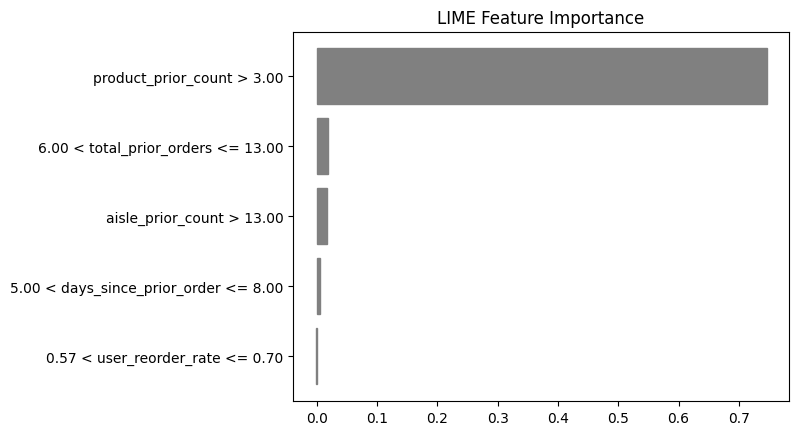

In [13]:
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

explainer = LimeTabularExplainer(
    X.values,
    feature_names=X.columns.tolist(),
    mode="classification"
)

def predict_fn(x):
    return model.predict_proba(x)

exp = explainer.explain_instance(
    X.values[0],
    predict_fn,
    num_features=5
)

print("LIME Explanation:\n")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

fig = exp.as_pyplot_figure()

for bar in fig.axes[0].patches:
    bar.set_color("gray")

plt.title("LIME Feature Importance")
plt.show()

## 15. Final Discussion (Model Optimization & Explainability)

The tuning results confirm that model performance varies with the number of latent components, highlighting the trade-off between accuracy and computational complexity.

The explainability analysis provides additional insight into user behavior by identifying key factors influencing predictions, supporting a better understanding of model decisions.

## 16. Testing Methodology

A temporal validation approach was used instead of traditional cross-validation to better simulate real-world deployment conditions. The dataset was split based on time, where past interactions were used for training and future interactions were used for testing.

The model was evaluated on unseen future interactions to ensure that predictions reflect realistic recommendation scenarios.

Additionally, due to computational constraints, a representative subset of users was used during evaluation and error analysis. This approach reduces processing time while maintaining consistent performance patterns.

Evaluation metrics include Precision@10 and Recall@10, which measure the relevance and coverage of recommended items.

## 17. Temporal Validation Results

This section summarizes the final recommendation performance of the selected model under a temporal validation setting. This extended validation helps assess model stability across different temporal slices.

In [14]:
temporal_results = pd.DataFrame({
    "metric": ["Precision@10", "Recall@10"],
    "score": [np.mean(precisions), np.mean(recalls)]
})

temporal_results

,metric,score
0,Precision@10,0.019665
1,Recall@10,0.019550


In [15]:
# Second-last order temporal validation

df_all = pd.concat([train, test])

second_last_orders = df_all.groupby("user_id")["order_number"].transform("max") - 1

val = df_all[df_all["order_number"] == second_last_orders].copy()

def precision_recall_val(user_id, k=10):
    recommended = set(get_top_n(user_id, k))
    actual = set(val[val["user_id"] == user_id]["product_id"])

    if len(actual) == 0:
        return 0, 0

    tp = len(recommended & actual)
    precision = tp / k
    recall = tp / len(actual)

    return precision, recall

val_precisions = []
val_recalls = []

for user in val["user_id"].unique():
    p, r = precision_recall_val(user)
    val_precisions.append(p)
    val_recalls.append(r)

print("Validation Precision@10:", np.mean(val_precisions))
print("Validation Recall@10:", np.mean(val_recalls))

Validation Precision@10: 0.0
Validation Recall@10: 0.0


## 18. Error Analysis and Common Failures

This section examines where the recommendation model is more likely to fail. In recommendation systems, users with limited interaction history are often harder to predict accurately.

To investigate this issue, user performance is grouped by purchase history length.

In [16]:
import pandas as pd

user_history_orders = train.groupby("user_id")["order_number"].nunique()

error_rows = []

eval_users_error = pd.Series(test["user_id"].unique()).sample(
    n=min(300, len(test["user_id"].unique())),
    random_state=42
)

for user in eval_users_error:
    recommended = set(get_top_n(user, 10))
    actual = set(test[test["user_id"] == user]["product_id"])

    if len(actual) == 0:
        continue

    tp = len(recommended & actual)
    precision = tp / 10
    recall = tp / len(actual)

    history_len = user_history_orders.get(user, 0)

    error_rows.append({
        "user_id": user,
        "history_len": history_len,
        "hit_count": tp,
        "precision@10": precision,
        "recall@10": recall
    })

error_df = pd.DataFrame(error_rows)

error_df["history_group"] = pd.cut(
    error_df["history_len"],
    bins=[0, 5, 15, 1000],
    labels=["low_history", "medium_history", "high_history"]
)

error_summary = error_df.groupby("history_group")[["precision@10", "recall@10", "hit_count"]].mean().reset_index()

zero_hit_rate = (error_df["hit_count"] == 0).mean()

print("Zero-hit rate:", zero_hit_rate)
error_summary

Zero-hit rate: 0.8566666666666667


/tmp/ipykernel_8306/2953601967.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_summary = error_df.groupby("history_group")[["precision@10", "recall@10", "hit_count"]].mean().reset_index()


,history_group,precision@10,recall@10,hit_count
0,low_history,0.028302,0.023557,0.283019
1,medium_history,0.015315,0.013445,0.153153
2,high_history,0.006024,0.004658,0.060241


In [17]:
# Zero-hit users analysis

zero_hit_users = []

for user in test["user_id"].unique():
    recs = set(get_top_n(user, 10))
    actual = set(test[test["user_id"] == user]["product_id"])

    if len(recs & actual) == 0:
        zero_hit_users.append(user)

print("Zero-hit users:", len(zero_hit_users))

Zero-hit users: 3460


## 19. Debugging and Reliability

The results indicate that the model is more likely to struggle when user interaction history is limited, highlighting a common cold-start limitation in recommendation systems. Users with fewer past interactions provide less information for the model, which can reduce prediction accuracy.

To improve reliability, several practices were followed throughout the workflow. A fixed random seed was used to ensure reproducibility, and a time-based train-test split was applied to prevent data leakage. Additionally, model configuration was selected based on prior tuning results to ensure stability.

This ensures consistent and reproducible results across multiple runs.

These steps contribute to a more robust and reliable recommendation system, supporting consistent evaluation and more realistic performance assessment.

## 20. Best Practices and Documentation

Several best practices were followed to improve reproducibility and maintainability. These include consistent random seeds, separation of training and testing data, and clearly structured notebook sections.

The workflow is documented in a step-by-step format to support readability, debugging, and future refinement. This approach aligns with technical documentation principles that emphasize clarity, consistency, and practical usability.

## 21. Final Discussion

The testing results provide additional evidence about model reliability and common failure cases. The temporal validation approach helps simulate real-world recommendation settings, while the error analysis shows that performance is weaker for users with limited history.

Overall, this stage strengthens the project by moving beyond model development and focusing on testing, debugging, reproducibility, and documentation.

## 22. Final Remarks

This notebook presents a complete and reproducible pipeline for building and evaluating a recommendation system under realistic conditions.

While the model provides baseline performance, the testing phase highlights key limitations such as temporal sensitivity and high zero-hit rates. These findings are important for guiding future improvements.

The overall workflow is designed to be extendable, allowing future work to focus on drift detection, retraining strategies, and production-level deployment.